### IMPORT LIBRARIES

### LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('churn_analysis.csv', compression='zip')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
import zipfile
import pandas as pd

# 1. Open the "fake" .csv (which is actually a .zip)
with zipfile.ZipFile('churn_analysis.csv', 'r') as z:
    
    z.extract('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### NULL VALES

In [4]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges: 11


In [5]:
# Fill missing TotalCharges with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify the data type is now a float
print(df['TotalCharges'].dtype)

float64


### Encode the Target Variable

In [6]:
# Convert Churn to binary (1 for Yes, 0 for No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Feature Engineering: Tenure Groups

In [7]:
def group_tenure(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    elif t <= 48: return '2-4 Years'
    else: return 'Over 4 Years'

df['TenureGroup'] = df['tenure'].apply(group_tenure)

### Visualization

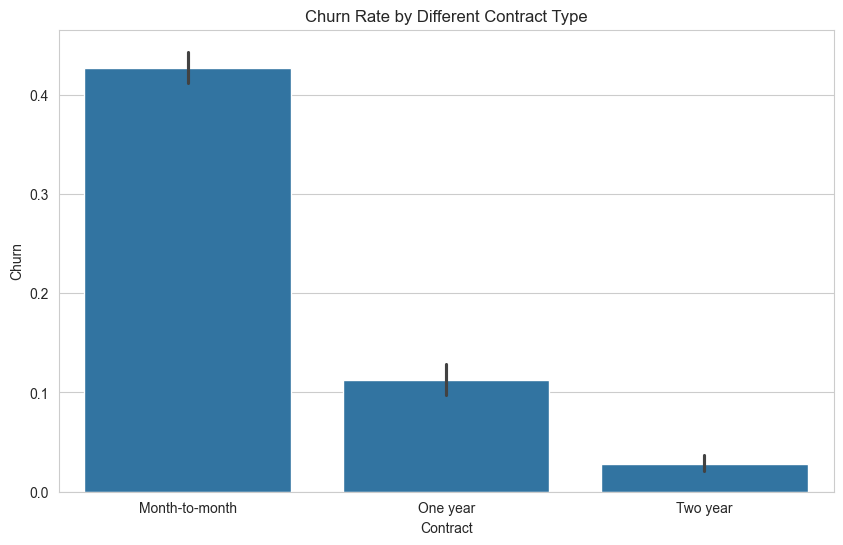

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title('Churn Rate by Different Contract Type')
plt.show()

### Binary Encoding

In [9]:
# 1. Convert the Target: Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Convert simple Yes/No features (Gender and Partner)
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

df[['gender', 'Partner', 'Churn']].head()

,gender,Partner,Churn
0,1,1,NaN
1,0,0,NaN
2,0,0,NaN
3,0,0,NaN
4,1,0,NaN


### Dropping Unwanted Data

In [10]:
# Drop the ID column as it holds no predictive power
df.drop('customerID', axis=1, inplace=True)

print(f"Remaining columns: {df.columns.tolist()}")

Remaining columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup']


### (The "Multi-Category" Fix)

In [11]:
# This creates dummy variables for all remaining text columns
df_final = pd.get_dummies(df, drop_first=True)

print(f"New shape after encoding: {df_final.shape}")
df_final.head()

New shape after encoding: (7043, 34)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 Years,TenureGroup_2-4 Years,TenureGroup_Over 4 Years
0,1,0,1,0,1,0,1,29.85,29.85,NaN,...,False,False,False,False,False,True,False,False,False,False
1,0,0,0,0,34,1,0,56.95,1889.50,NaN,...,False,False,True,False,False,False,True,False,True,False
2,0,0,0,0,2,1,1,53.85,108.15,NaN,...,False,False,False,False,False,False,True,False,False,False
3,0,0,0,0,45,0,0,42.30,1840.75,NaN,...,False,False,True,False,False,False,False,False,True,False
4,1,0,0,0,2,1,1,70.70,151.65,NaN,...,False,False,False,False,False,True,False,False,False,False


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data
# Using the extracted filename we saw in your zip file earlier
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Clean Data
# Fix TotalCharges (turning blanks into 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Binary Encoding for simple Yes/No columns
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df.drop('customerID', axis=1, inplace=True)

# 3. Create df_final 
df_final = pd.get_dummies(df, drop_first=True)
df_final.columns = df_final.columns.str.strip() # Remove hidden spaces

# 4. Define Correlation (This fixes your second NameError!)
correlation = df_final.corr()

print("Memory restored! 'df_final' and 'correlation' are now ready.")

Memory restored! 'df_final' and 'correlation' are now ready.


### Visualization (Finding the "Why")

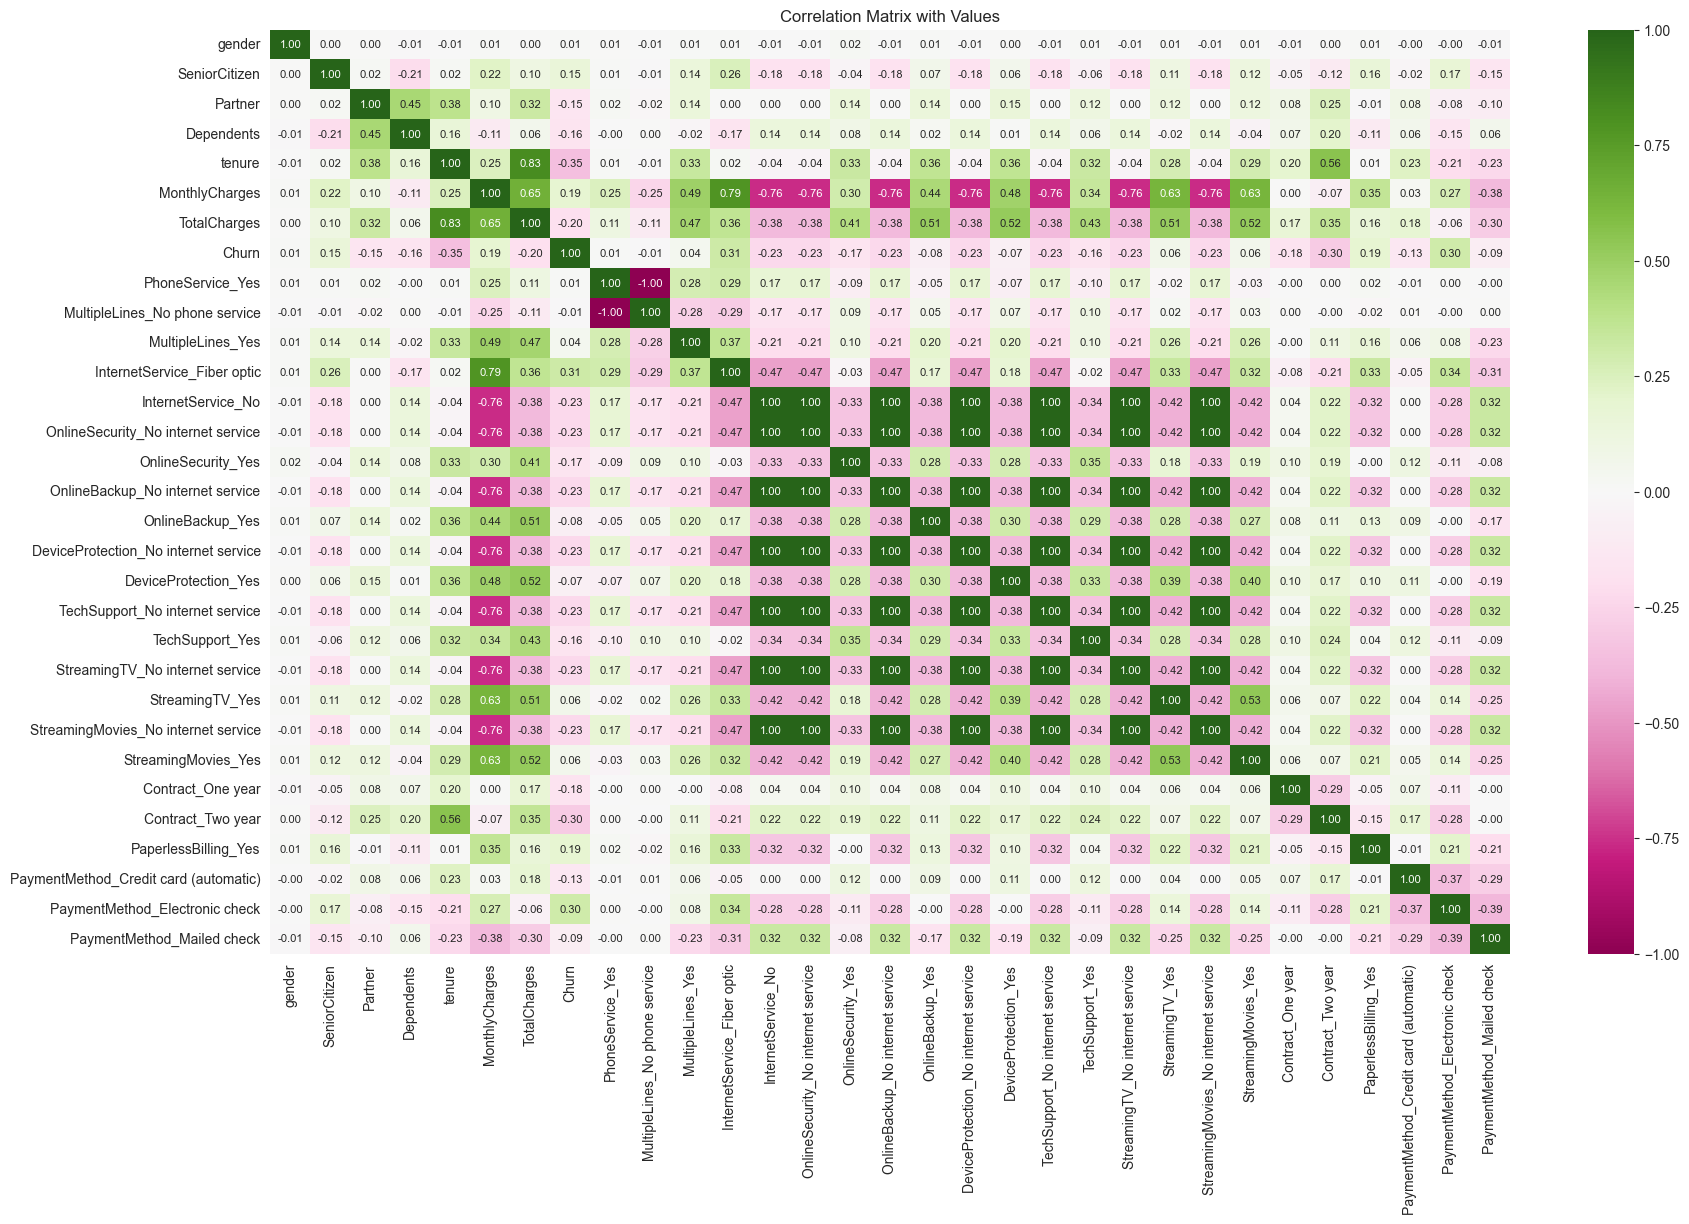

In [13]:
plt.figure(figsize=(20, 12))

# annot=True puts the numbers inside
# fmt='.2f' rounds to 2 decimal places
# annot_kws sets the font size so it's not too cramped
sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='PiYG', 
            center=0,
            annot_kws={"size": 8}) 

plt.title('Correlation Matrix with Values')
plt.show()

### TOP DRIVERS COREELATION WITH CHURN

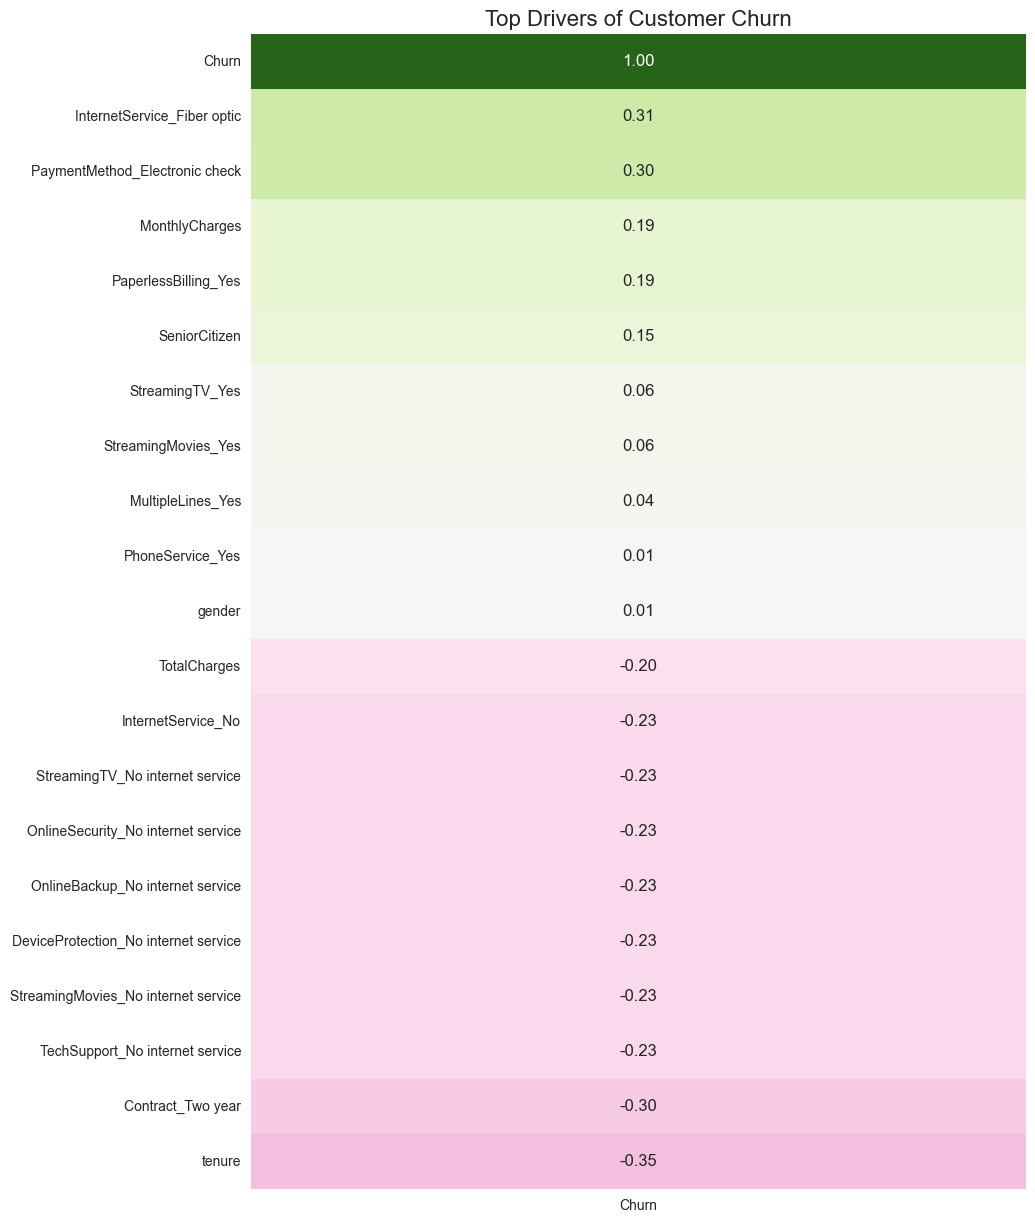

In [14]:
# 1. Clean up column names (removes hidden spaces and fixes case)
df_final.columns = df_final.columns.str.strip()

# 2. Check if 'Churn' actually exists in your dataframe right now
if 'Churn' not in df_final.columns:
    print("Warning: 'Churn' column not found. Let's find out what it's named:")
    print([col for col in df_final.columns if 'churn' in col.lower()])
else:
    churn_corr = df_final.corr()['Churn'].sort_values(ascending=False)

    top_corr = pd.concat([churn_corr.head(11), churn_corr.tail(10)])

    plt.figure(figsize=(10, 15))
    sns.heatmap(top_corr.to_frame(), 
                annot=True, 
                fmt='.2f', 
                cmap='PiYG', 
                center=0,
                annot_kws={"size": 12}, 
                cbar=False)

    plt.title('Top Drivers of Customer Churn', fontsize=16)
    plt.show()

### The "Class Imbalance" Check

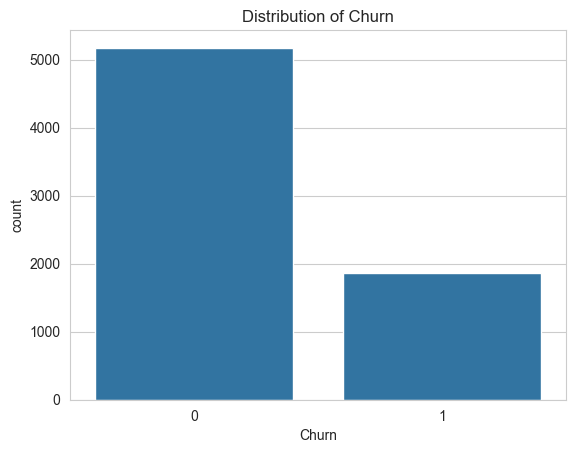

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [15]:
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

# Get exact percentages
print(df['Churn'].value_counts(normalize=True) * 100)

### Install sklearn.model

In [16]:
import sys
!{sys.executable} -m pip install scikit-learn

### Splitting the Data

In [17]:
from sklearn.model_selection import train_test_split

# 1. Define X and y
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")

Training set size: 5634 customers
Testing set size: 1409 customers


### Train the Model using Logistics Regression

In [28]:
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Retrain the model on the SCALED data
model = LogisticRegression(max_iter=2000) 
model.fit(X_train_scaled, y_train)

print("Model trained with scaled data")

Model trained with scaled data


### Accuracy Check

In [27]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

Final Model Accuracy: 82.04%


### The Business Insight (The So What?)

In [22]:
# 1. Get the importance of each feature
# Since we scaled the data, we can compare these numbers directly
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

# 2. Look at the Top 5 reasons people LEAVE (Positive Importance)
print("Top Reasons for Churn:")
print(importance.head(5))

# 3. Look at the Top 5 reasons people STAY (Negative Importance)
print("\nTop Reasons for Loyalty:")
print(importance.tail(5))

Top Reasons for Churn:
                        Feature  Importance
6                  TotalCharges    0.649427
10  InternetService_Fiber optic    0.619853
23          StreamingMovies_Yes    0.228714
21              StreamingTV_Yes    0.179380
9             MultipleLines_Yes    0.168199

Top Reasons for Loyalty:
               Feature  Importance
13  OnlineSecurity_Yes   -0.158642
24   Contract_One year   -0.268336
25   Contract_Two year   -0.613702
5       MonthlyCharges   -0.628014
4               tenure   -1.347355


### Confusion Matirx

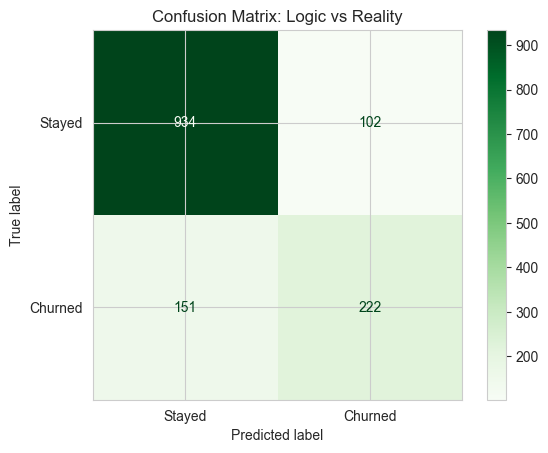

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Create the matrix using the scaled predictions
predictions_scaled = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, predictions_scaled)

# 2. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix: Logic vs Reality')
plt.show()

### Train the Model using Random forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Train the Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Random Forest handles raw data well!

# 2. Score it
rf_preds = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")

Random Forest Accuracy: 79.99%


### Confusion Matirx

<Figure size 800x600 with 0 Axes>

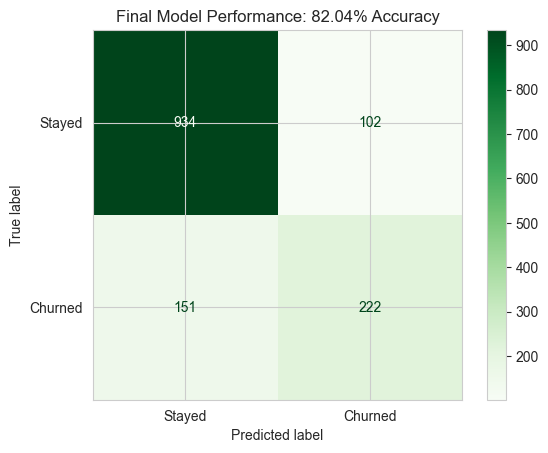

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. GENERATE THE PREDICTIONS (This fixes your NameError!)
# We use X_test_scaled because your 82% model was trained on scaled data
predictions = model.predict(X_test_scaled)

# 2. Create the matrix
cm = confusion_matrix(y_test, predictions)

# 3. Plot it
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Greens', values_format='d')

plt.title('Final Model Performance: 82.04% Accuracy')
plt.show()